# DATASET OVERALL INFO

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import xgboost as xgb
from sklearn.cluster import KMeans
from scipy.stats import iqr
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import confusion_matrix, classification_report, make_scorer, f1_score, roc_auc_score, precision_score, recall_score, matthews_corrcoef, roc_curve, auc
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/nguynnamhong1/transaction/transactions_synthetic.csv")

# Kiểm tra thông tin DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 23 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   step                         int64  
 1   type                         object 
 2   amount                       float64
 3   nameOrig                     object 
 4   oldbalanceOrg                float64
 5   newbalanceOrig               float64
 6   nameDest                     object 
 7   oldbalanceDest               float64
 8   newbalanceDest               float64
 9   isFraud                      int64  
 10  isFlaggedFraud               int64  
 11  hour_of_day                  int64  
 12  is_night_transaction         bool   
 13  customer_account_age_days    int64  
 14  device_id                    object 
 15  browser                      object 
 16  device_type                  object 
 17  new_device_flag              bool   
 18  billing_country              object 
 19  

In [4]:
# Kích thước dữ liệu
print(df.shape)

(6362620, 23)


In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,customer_account_age_days,device_id,browser,device_type,new_device_flag,billing_country,ip_country,ip_billing_distance_km,shipping_billing_mismatch,failed_payment_attempts_24h
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,...,480,2dab3a2d-19b5-4c6d-9e20-1a6fc0e03eae,Safari,desktop,False,VN,VN,0.000000,False,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,...,214,d7ba5ab8-3144-4f97-8d7d-9da933cb6289,Edge,mobile,False,DE,DE,0.000000,False,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,...,431,1063f2a6-0b75-4c9e-9b1c-0589b03189b5,Chrome,mobile,False,CN,CN,0.000000,False,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,...,484,34e46f07-380c-452f-a294-5c5936981525,Safari,mobile,False,VN,VN,0.000000,False,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,...,124,e6194e21-453e-4f1b-b638-4acdcbec7ade,Chrome,mobile,False,RU,US,8540.538359,False,0


## Missing, duplicate check

In [52]:
# ================================
# Check Missing Values
# ================================

missing_counts = df.isnull().sum()

missing_percent = (
    missing_counts / len(df) * 100
).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percent
})

# Chỉ hiển thị các cột có missing
missing_summary = missing_summary[
    missing_summary['Missing Count'] > 0
]

print("========== MISSING VALUES SUMMARY ==========\n")

if missing_summary.empty:
    print("No missing values found in the dataset.")
else:
    print(missing_summary)


# ================================
# Check Duplicate Rows
# ================================

duplicate_count = df.duplicated().sum()

duplicate_percent = round(
    duplicate_count / len(df) * 100,
    4
)

print("\n========== DUPLICATE ROWS SUMMARY ==========\n")

print(f"Duplicate Rows       : {duplicate_count:,}")
print(f"Duplicate Percentage : {duplicate_percent}%")

if duplicate_count == 0:
    print("No duplicate rows found in the dataset.")

========== MISSING VALUES SUMMARY ==========

No missing values found in the dataset.

========== DUPLICATE ROWS SUMMARY ==========

Duplicate Rows       : 0
Duplicate Percentage : 0.0%
No duplicate rows found in the dataset.


# Explore on transaction type

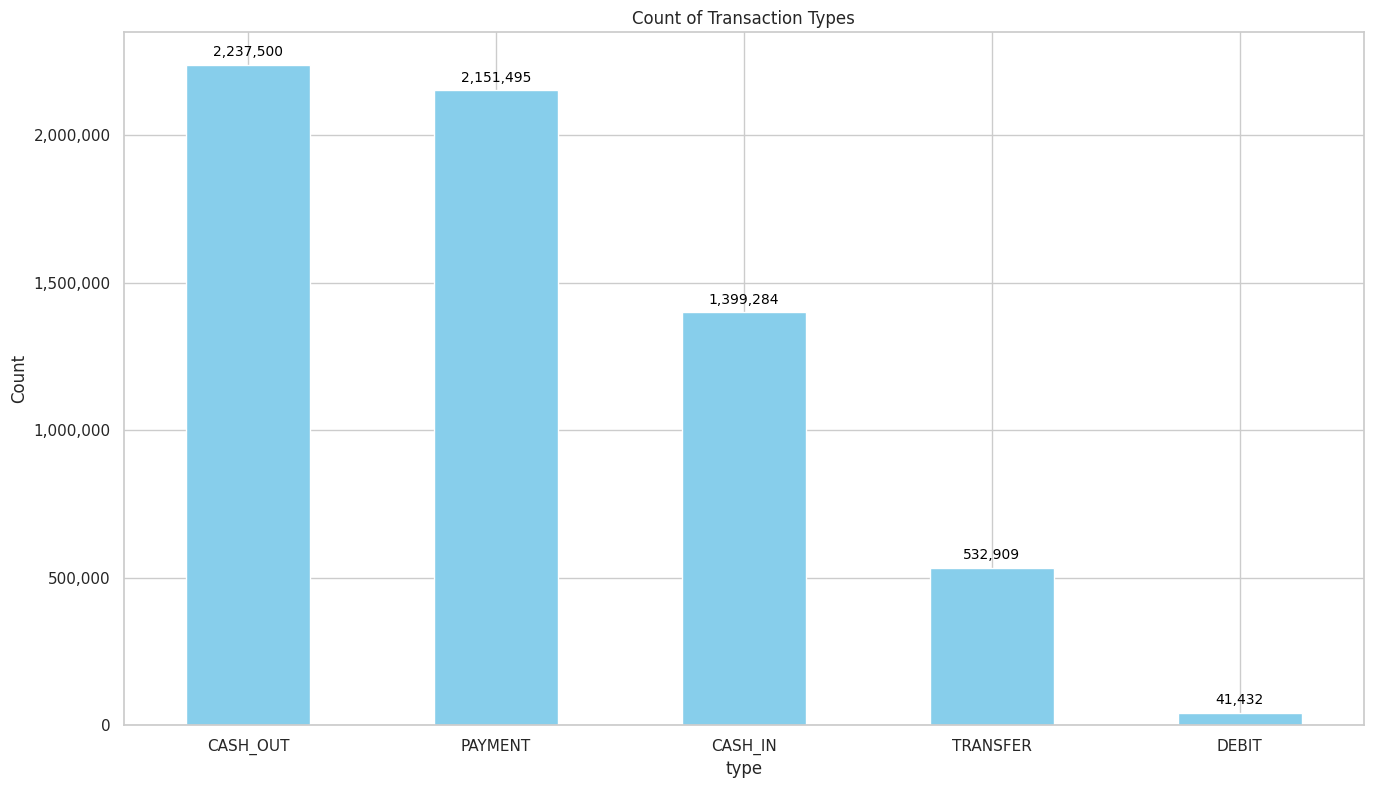

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

unique_types = df['type'].unique()
type_counts = df['type'].value_counts()

plt.figure(figsize=(16, 9))
plt.title('Count of Transaction Types')
plt.xlabel('Transaction Type')
plt.ylabel('Count')

bars = type_counts.plot(
    kind='bar',
    color='skyblue',
    rot=0  
)

for bar in bars.patches:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 20000,
        f'{yval:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f'{value:,.0f}')
)

plt.show()

There are five distinct types of transactions in the dataset: PAYMENT, TRANSFER, CASH_OUT, DEBIT, and CASH_IN.

The distribution of these transaction types is as follows:

* CASH_OUT: 2,237,500 transactions  
* PAYMENT: 2,151,495 transactions  
* CASH_IN: 1,399,284 transactions  
* TRANSFER: 532,909 transactions  
* DEBIT: 41,432 transactions  

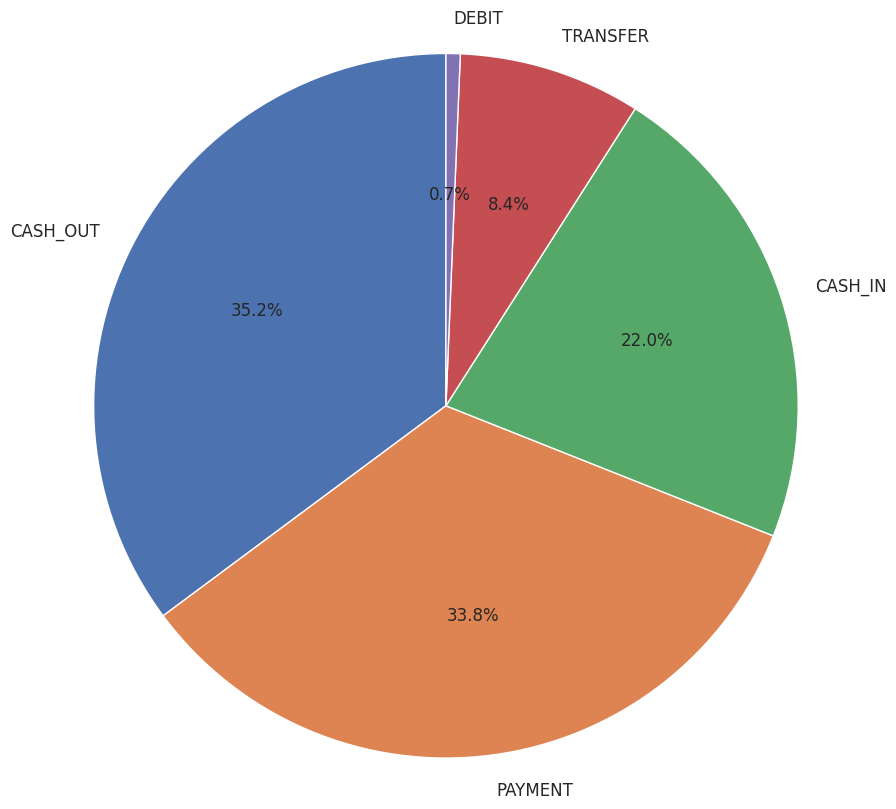

In [12]:
import matplotlib.pyplot as plt

type_counts = df['type'].value_counts()

plt.figure(figsize=(10, 10))

plt.pie(
    type_counts,
    labels=type_counts.index,          
    autopct='%1.1f%%',                
    startangle=90,                    
    textprops={'fontsize': 12}
)

plt.axis('equal') 

plt.show()

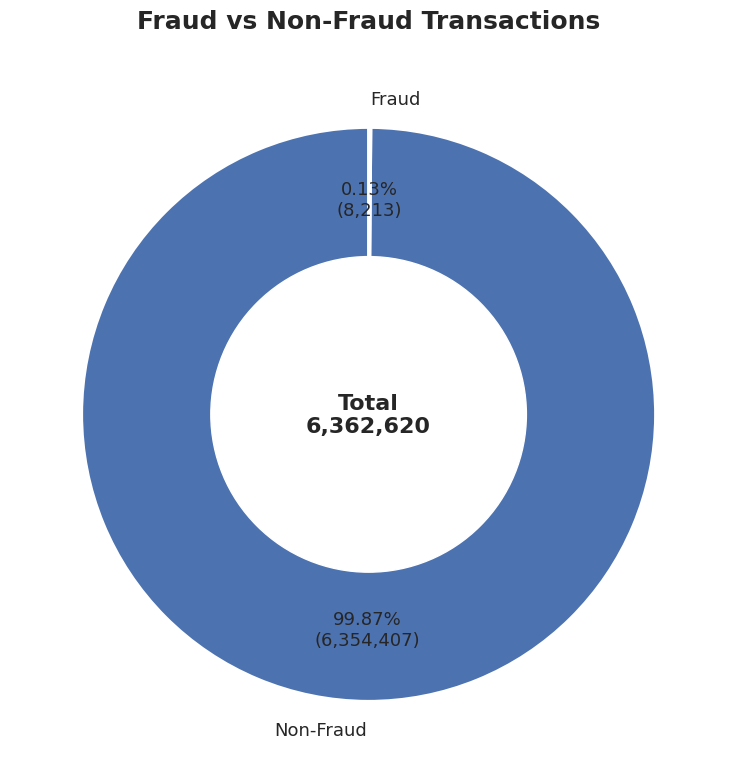

In [14]:
import matplotlib.pyplot as plt

# Count fraud / non-fraud
fraud_count = df[df["isFraud"] == 1].shape[0]
non_fraud_count = df[df["isFraud"] == 0].shape[0]

labels = ['Non-Fraud', 'Fraud']
sizes = [non_fraud_count, fraud_count]
colors = ['#4C72B0', '#DD4B39']

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.2f}%\n({val:,})'
    return my_format

plt.figure(figsize=(10, 8))

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=autopct_format(sizes),
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 13},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)


centre_circle = plt.Circle((0, 0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)


plt.title(
    'Fraud vs Non-Fraud Transactions',
    fontsize=18,
    fontweight='bold',
    pad=20
)

total = fraud_count + non_fraud_count

plt.text(
    0, 0,
    f'Total\n{total:,}',
    ha='center',
    va='center',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

This highly imbalanced distribution, where the number of non-fraudulent transactions substantially outweighs the number of fraudulent transactions, can pose challenges during model training. It is crucial to address this class imbalance to ensure that the machine learning model does not become biased towards the majority class, leading to suboptimal performance in identifying the minority class (fraudulent transactions)

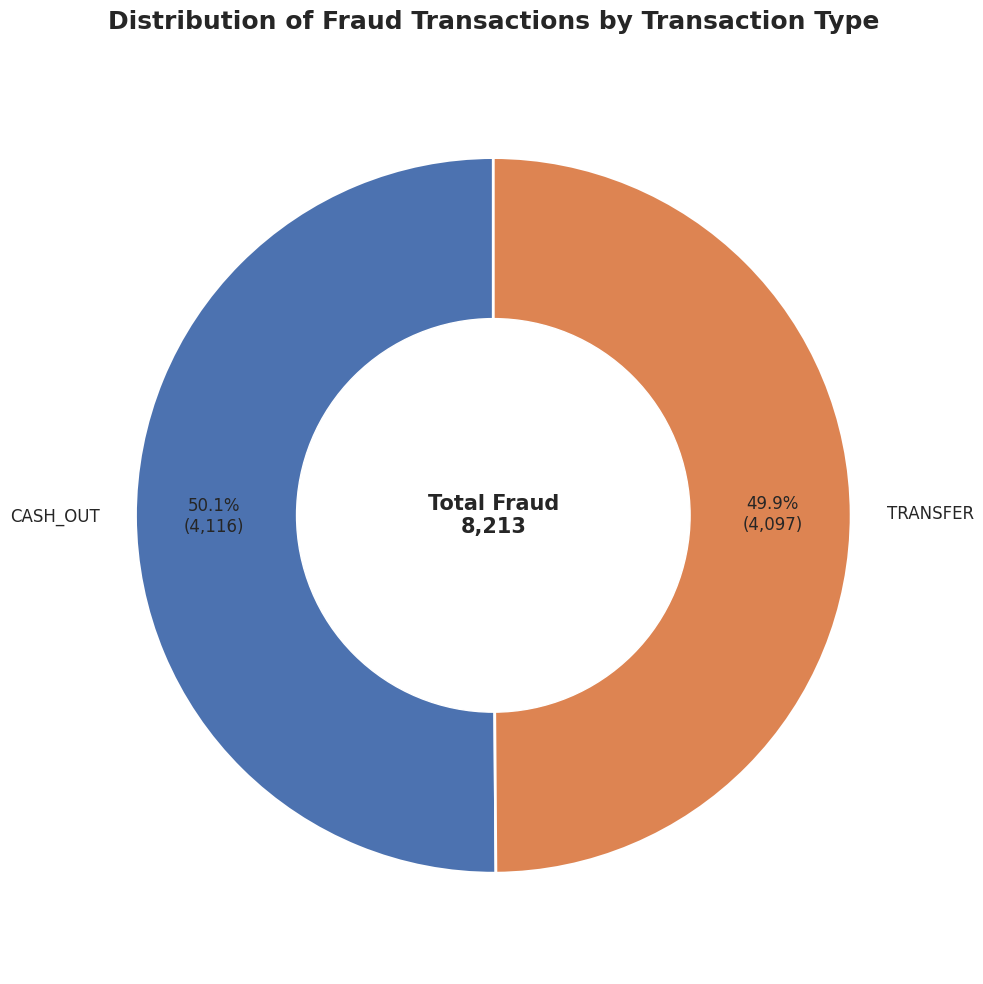

In [19]:
import matplotlib.pyplot as plt

fraud_df = df[df['isFraud'] == 1]
fraud_type_counts = fraud_df['type'].value_counts()

def custom_autopct(pct):
    total = fraud_type_counts.sum()
    count = int(round(pct * total / 100))
    return f'{pct:.1f}%\n({count:,})'

plt.figure(figsize=(10, 10))

# Pie chart
wedges, texts, autotexts = plt.pie(
    fraud_type_counts,
    labels=fraud_type_counts.index,
    autopct=custom_autopct,
    startangle=90,
    pctdistance=0.78,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

centre_circle = plt.Circle((0, 0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(
    'Distribution of Fraud Transactions by Transaction Type',
    fontsize=18,
    fontweight='bold',
    pad=20
)

total_fraud = fraud_type_counts.sum()

plt.text(
    0, 0,
    f'Total Fraud\n{total_fraud:,}',
    ha='center',
    va='center',
    fontsize=15,
    fontweight='bold'
)

plt.axis('equal')

plt.tight_layout()
plt.show()

This concentration of fraud within CASH_OUT and TRANSFER transactions suggests that these specific types may be more susceptible to fraudulent activities

# Check fraud on orig account and dest account

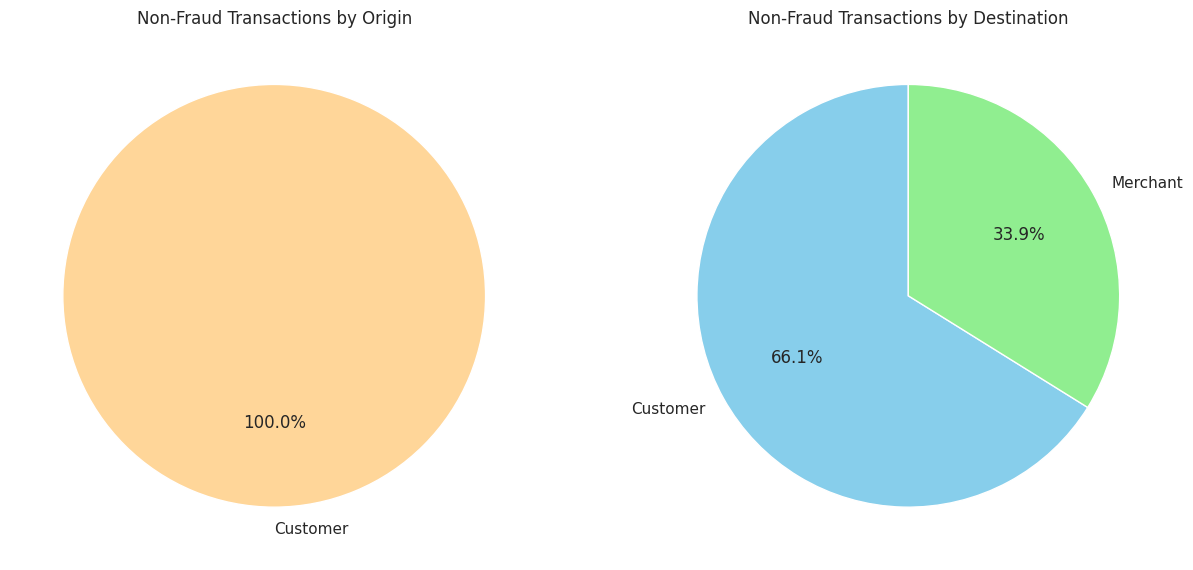

In [23]:
non_fraud_transactions = df[df['isFraud'] == 0].copy()
non_fraud_transactions['nameOrg_first_letter'] = non_fraud_transactions['nameOrig'].str[0]
non_fraud_transactions['nameDest_first_letter'] = non_fraud_transactions['nameDest'].str[0]
non_fraud_transactions['nameOrg_first_letter'] = non_fraud_transactions['nameOrg_first_letter'].replace({'C': 'Customer', 'M': 'Merchant'})
non_fraud_transactions['nameDest_first_letter'] = non_fraud_transactions['nameDest_first_letter'].replace({'C': 'Customer', 'M': 'Merchant'})

non_fraud_by_name_orig_first_letter = non_fraud_transactions.groupby('nameOrg_first_letter').size()
non_fraud_by_name_dest_first_letter = non_fraud_transactions.groupby('nameDest_first_letter').size()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))


axes[0].pie(non_fraud_by_name_orig_first_letter, labels=non_fraud_by_name_orig_first_letter.index, autopct='%1.1f%%', startangle=90, colors=[light_orange, 'lightcoral'])
axes[0].set_title('Non-Fraud Transactions by Origin')
axes[1].pie(non_fraud_by_name_dest_first_letter, labels=non_fraud_by_name_dest_first_letter.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen'])
axes[1].set_title('Non-Fraud Transactions by Destination')

plt.show()

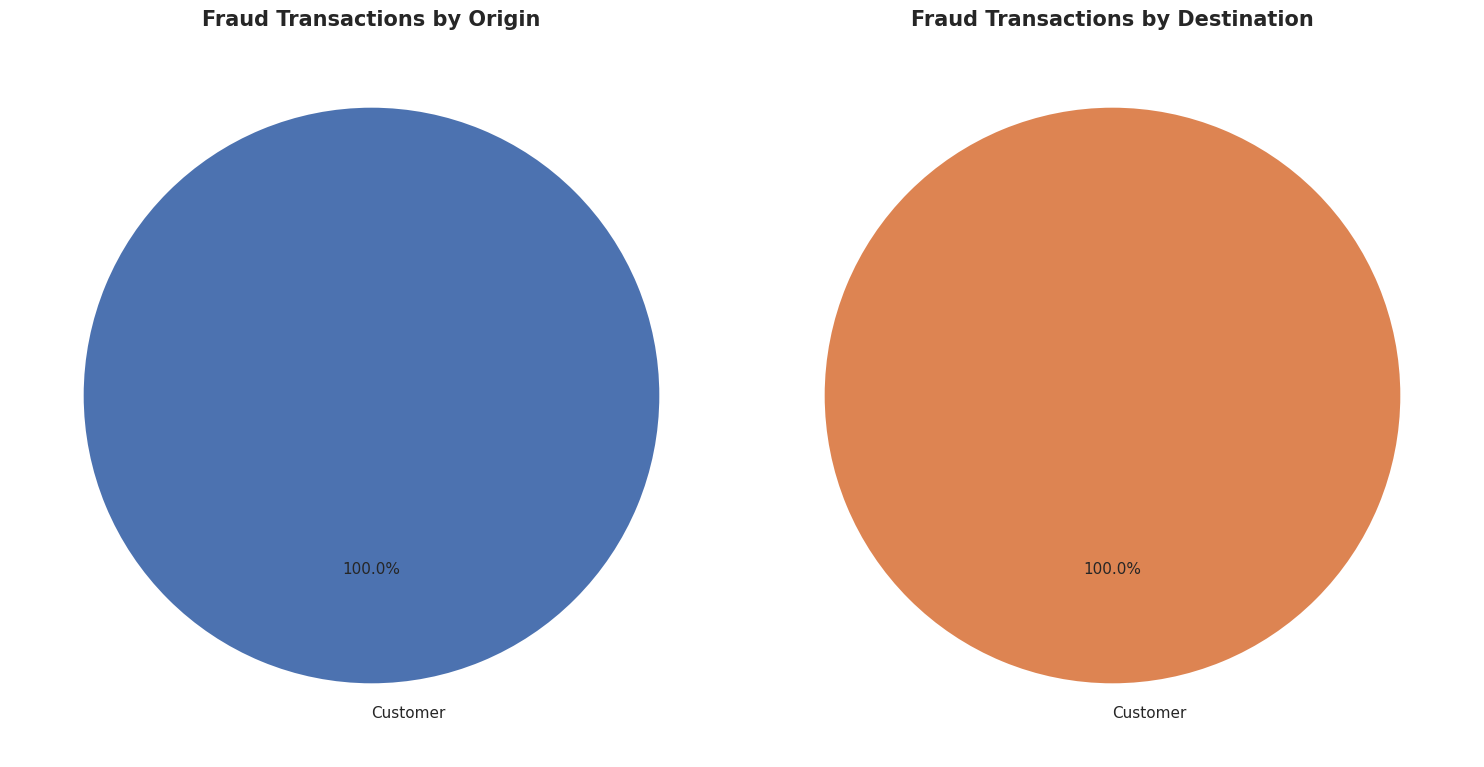

In [21]:
import matplotlib.pyplot as plt

fraud_transactions = df[df['isFraud'] == 1].copy()

fraud_transactions['nameOrg_first_letter'] = fraud_transactions['nameOrig'].str[0]
fraud_transactions['nameDest_first_letter'] = fraud_transactions['nameDest'].str[0]

fraud_transactions['nameOrg_first_letter'] = (
    fraud_transactions['nameOrg_first_letter']
    .replace('C', 'Customer')
)

fraud_transactions['nameDest_first_letter'] = (
    fraud_transactions['nameDest_first_letter']
    .replace('C', 'Customer')
)

fraud_by_name_orig_first_letter = (
    fraud_transactions.groupby('nameOrg_first_letter').size()
)

fraud_by_name_dest_first_letter = (
    fraud_transactions.groupby('nameDest_first_letter').size()
)

# Màu đẹp hơn
origin_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
dest_colors = ['#DD8452', '#64B5CD', '#937860', '#DA8BC3']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))

# Origin Pie Chart
axes[0].pie(
    fraud_by_name_orig_first_letter,
    labels=fraud_by_name_orig_first_letter.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=origin_colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)

axes[0].set_title(
    'Fraud Transactions by Origin',
    fontsize=15,
    fontweight='bold'
)

# Destination Pie Chart
axes[1].pie(
    fraud_by_name_dest_first_letter,
    labels=fraud_by_name_dest_first_letter.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=dest_colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)

axes[1].set_title(
    'Fraud Transactions by Destination',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

The analysis of fraud transactions reveals a distinct pattern: all fraudulent transactions involve interactions between customers, both as the originators and recipients. This implies that fraudulent activities, as identified in the dataset, exclusively occur within transactions involving customers on both ends.

# Fraud rate check on some important features 

## AMOUNT

In [28]:
print("========== DESCRIPTIVE STATISTICS FOR AMOUNT ==========\n")

print(df['amount'].describe())

# Quantiles
print("\n========== QUANTILES ==========\n")

quantiles = df['amount'].quantile([
    0.2,
    0.4,
    0.6,
    0.8,
    1
])

print(quantiles)

========== DESCRIPTIVE STATISTICS FOR AMOUNT ==========

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

========== QUANTILES ==========

0.2    9.866158e+03
0.4    3.637135e+04
0.6    1.225638e+05
0.8    2.466112e+05
1.0    9.244552e+07
Name: amount, dtype: float64


/tmp/ipykernel_58/30808421.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('amount_range')['isFraud']


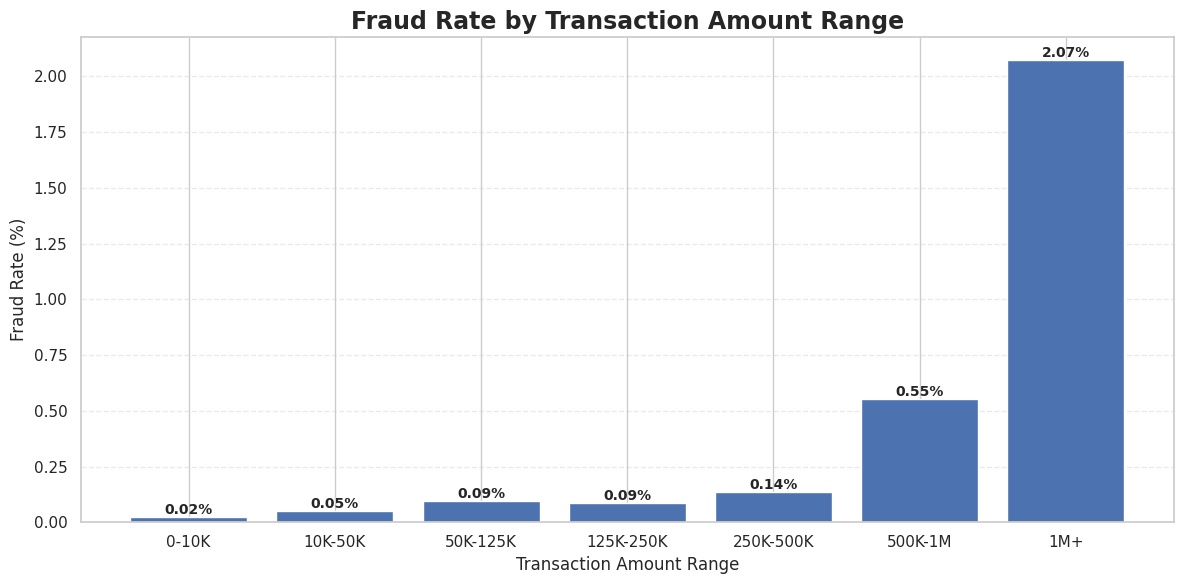

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Amount bins dựa trên quantile thực tế
amount_bins = [
    0,
    10000,      # ~20%
    50000,
    125000,     # ~60%
    250000,     # ~80%
    500000,
    1000000,
    df['amount'].max()
]

amount_labels = [
    '0-10K',
    '10K-50K',
    '50K-125K',
    '125K-250K',
    '250K-500K',
    '500K-1M',
    '1M+'
]

# Create amount range
df['amount_range'] = pd.cut(
    df['amount'],
    bins=amount_bins,
    labels=amount_labels,
    include_lowest=True
)

fraud_rate_amount = (
    df.groupby('amount_range')['isFraud']
    .mean()
    .mul(100)
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    fraud_rate_amount.index.astype(str),
    fraud_rate_amount.values
)

for bar in bars:
    y = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{y:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Fraud Rate by Transaction Amount Range',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Transaction Amount Range')
plt.ylabel('Fraud Rate (%)')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Account age

In [36]:
import pandas as pd

age_bins = [0, 30, 90, 180, 365, 730, df['customer_account_age_days'].max()]
age_labels = [
    '0-30d',
    '30-90d',
    '90-180d',
    '180-365d',
    '1-2y',
    '2y+'
]

df['account_age_group'] = pd.cut(
    df['customer_account_age_days'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

account_age_counts = (
    df['account_age_group']
    .value_counts()
    .sort_index()
)

account_age_percent = (
    account_age_counts / len(df) * 100
).round(2)

account_age_summary = pd.DataFrame({
    'Count': account_age_counts,
    'Percentage (%)': account_age_percent
})

print(account_age_summary)

                     Count  Percentage (%)
account_age_group                         
0-30d                   58            0.00
30-90d               42526            0.67
90-180d             545757            8.58
180-365d           2213050           34.78
1-2y               2558169           40.21
2y+                1003060           15.76


/tmp/ipykernel_58/1202356522.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('account_age_group')['isFraud']


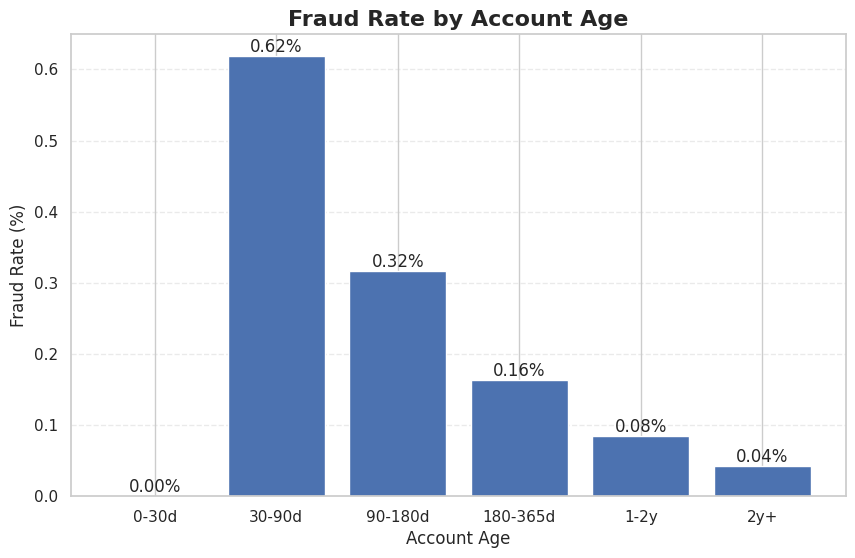

In [30]:
age_bins = [0, 30, 90, 180, 365, 730, df['customer_account_age_days'].max()]
age_labels = [
    '0-30d',
    '30-90d',
    '90-180d',
    '180-365d',
    '1-2y',
    '2y+'
]

df['account_age_group'] = pd.cut(
    df['customer_account_age_days'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

fraud_rate_age = (
    df.groupby('account_age_group')['isFraud']
    .mean()
    .mul(100)
)

plt.figure(figsize=(10, 6))
bars = plt.bar(fraud_rate_age.index.astype(str), fraud_rate_age.values)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{y:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title('Fraud Rate by Account Age', fontsize=16, fontweight='bold')
plt.xlabel('Account Age')
plt.ylabel('Fraud Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

## DEVICE & BROWSER

In [34]:
import pandas as pd

device_counts = (
    df['device_type']
    .value_counts()
)

device_percent = (
    device_counts / len(df) * 100
).round(2)

device_summary = pd.DataFrame({
    'Count': device_counts,
    'Percentage (%)': device_percent
})

print("========== DEVICE TYPE DISTRIBUTION ==========\n")
print(device_summary)

browser_counts = (
    df['browser']
    .value_counts()
)

browser_percent = (
    browser_counts / len(df) * 100
).round(2)

browser_summary = pd.DataFrame({
    'Count': browser_counts,
    'Percentage (%)': browser_percent
})

print("\n========== BROWSER DISTRIBUTION ==========\n")
print(browser_summary)

========== DEVICE TYPE DISTRIBUTION ==========

               Count  Percentage (%)
device_type                         
mobile       4136594           65.01
desktop      1908202           29.99
tablet        317824            5.00

========== BROWSER DISTRIBUTION ==========

           Count  Percentage (%)
browser                         
Chrome   3498073           54.98
Safari   1272412           20.00
Edge      764302           12.01
Firefox   509104            8.00
Other     318729            5.01


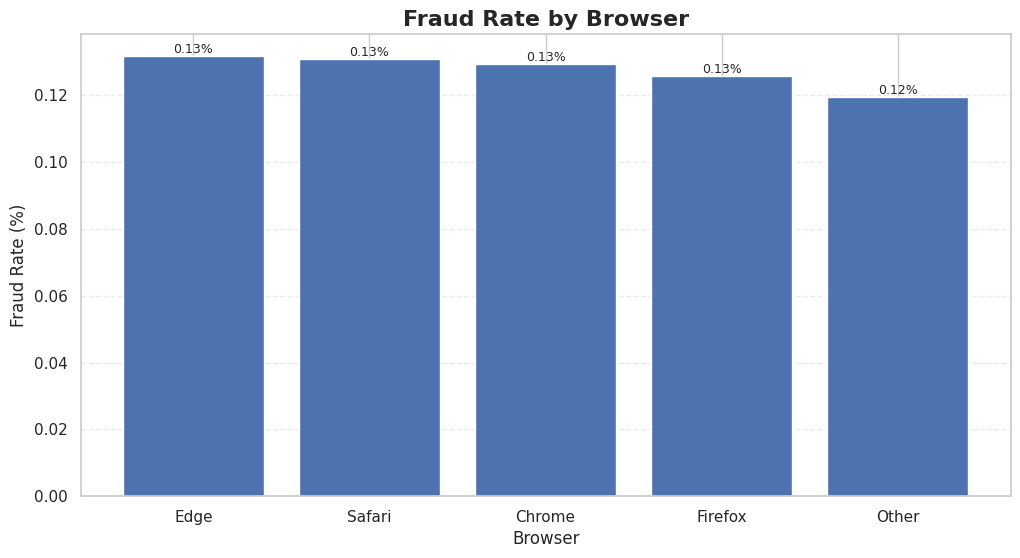

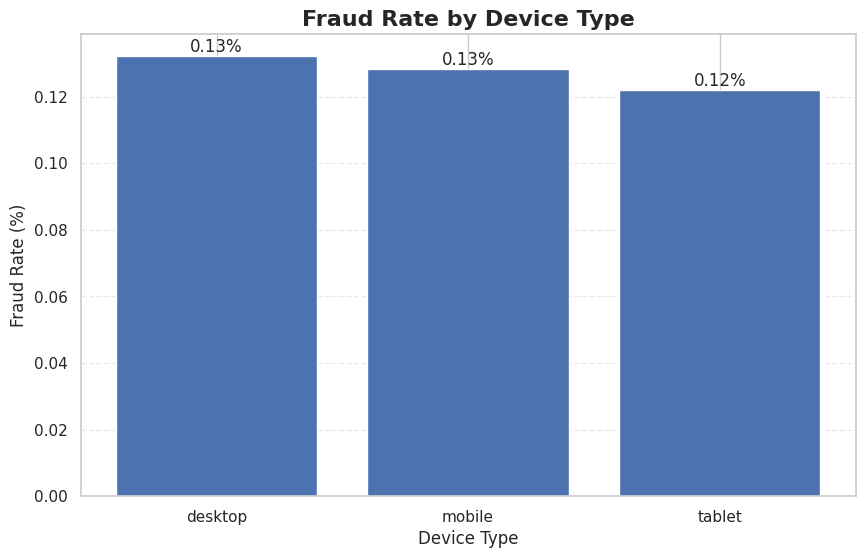

In [33]:
fraud_rate_browser = (
    df.groupby('browser')['isFraud']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
bars = plt.bar(fraud_rate_browser.index.astype(str), fraud_rate_browser.values)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{y:.2f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Fraud Rate by Browser', fontsize=16, fontweight='bold')
plt.xlabel('Browser')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


fraud_rate_device = (
    df.groupby('device_type')['isFraud']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
bars = plt.bar(fraud_rate_device.index.astype(str), fraud_rate_device.values)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{y:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title('Fraud Rate by Device Type', fontsize=16, fontweight='bold')
plt.xlabel('Device Type')
plt.ylabel('Fraud Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

## Fraud on shipping/billing missmatch

In [38]:
import pandas as pd

mismatch_counts = (
    df['shipping_billing_mismatch']
    .value_counts()
)

mismatch_percent = (
    mismatch_counts / len(df) * 100
).round(2)

mismatch_summary = pd.DataFrame({
    'Count': mismatch_counts,
    'Percentage (%)': mismatch_percent
})

print("========== SHIPPING / BILLING MISMATCH DISTRIBUTION ==========\n")
print(mismatch_summary)

========== SHIPPING / BILLING MISMATCH DISTRIBUTION ==========

                             Count  Percentage (%)
shipping_billing_mismatch                         
False                      6044014           94.99
True                        318606            5.01


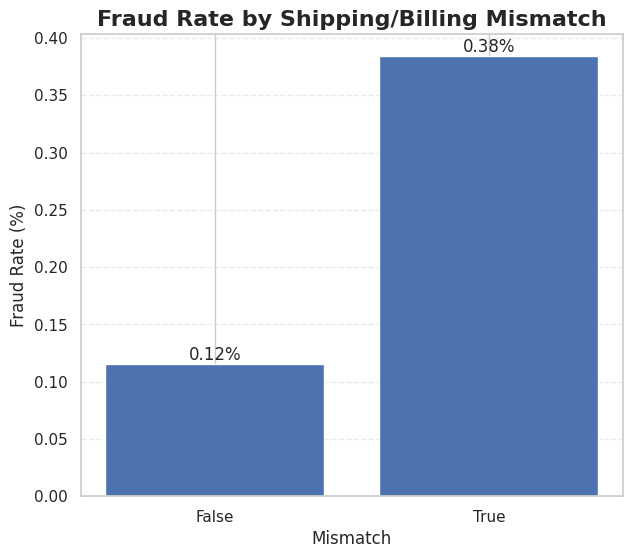

In [37]:
fraud_rate_mismatch = (
    df.groupby('shipping_billing_mismatch')['isFraud']
    .mean()
    .mul(100)
)

plt.figure(figsize=(7, 6))
bars = plt.bar(
    fraud_rate_mismatch.index.astype(str),
    fraud_rate_mismatch.values
)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{y:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title(
    'Fraud Rate by Shipping/Billing Mismatch',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Mismatch')
plt.ylabel('Fraud Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

## Fraud on 'failed_payment_attempts'

In [40]:
import pandas as pd

failed_attempts_counts = (
    df['failed_payment_attempts_24h']
    .value_counts()
    .sort_index()
)

failed_attempts_percent = (
    failed_attempts_counts / len(df) * 100
).round(2)

failed_attempts_summary = pd.DataFrame({
    'Count': failed_attempts_counts,
    'Percentage (%)': failed_attempts_percent
})

print("========== FAILED PAYMENT ATTEMPTS (24H) DISTRIBUTION ==========\n")
print(failed_attempts_summary)

========== FAILED PAYMENT ATTEMPTS (24H) DISTRIBUTION ==========

                               Count  Percentage (%)
failed_payment_attempts_24h                         
0                            5474377           86.04
1                             822545           12.93
2                              62325            0.98
3                               3220            0.05
4                                147            0.00
5                                  6            0.00


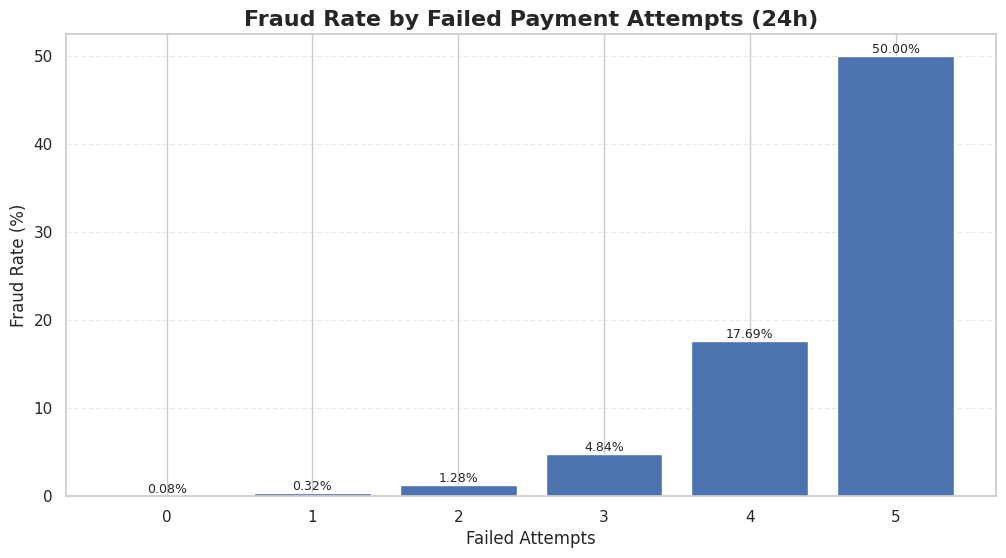

In [39]:
failed_attempts_rate = (
    df.groupby('failed_payment_attempts_24h')['isFraud']
    .mean()
    .mul(100)
)

plt.figure(figsize=(12, 6))
bars = plt.bar(
    failed_attempts_rate.index.astype(str),
    failed_attempts_rate.values
)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{y:.2f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title(
    'Fraud Rate by Failed Payment Attempts (24h)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Failed Attempts')
plt.ylabel('Fraud Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

## Fraud on hour

In [44]:
import pandas as pd

hour_counts = (
    df['hour_of_day']
    .value_counts()
    .sort_index()
)

hour_percent = (
    hour_counts / len(df) * 100
).round(2)

hour_summary = pd.DataFrame({
    'Count': hour_counts,
    'Percentage (%)': hour_percent
})

print("========== HOUR OF DAY DISTRIBUTION ==========\n")
print(hour_summary)

========== HOUR OF DAY DISTRIBUTION ==========

              Count  Percentage (%)
hour_of_day                        
0             27111            0.43
1              9018            0.14
2              2007            0.03
3              1241            0.02
4              1641            0.03
5              3420            0.05
6              8988            0.14
7             26915            0.42
8            283518            4.46
9            425729            6.69
10           445992            7.01
11           483418            7.60
12           468474            7.36
13           439653            6.91
14           416686            6.55
15           441612            6.94
16           439941            6.91
17           580509            9.12
18           647814           10.18
19           553728            8.70
20           247806            3.89
21           194555            3.06
22           141257            2.22
23            71587            1.13


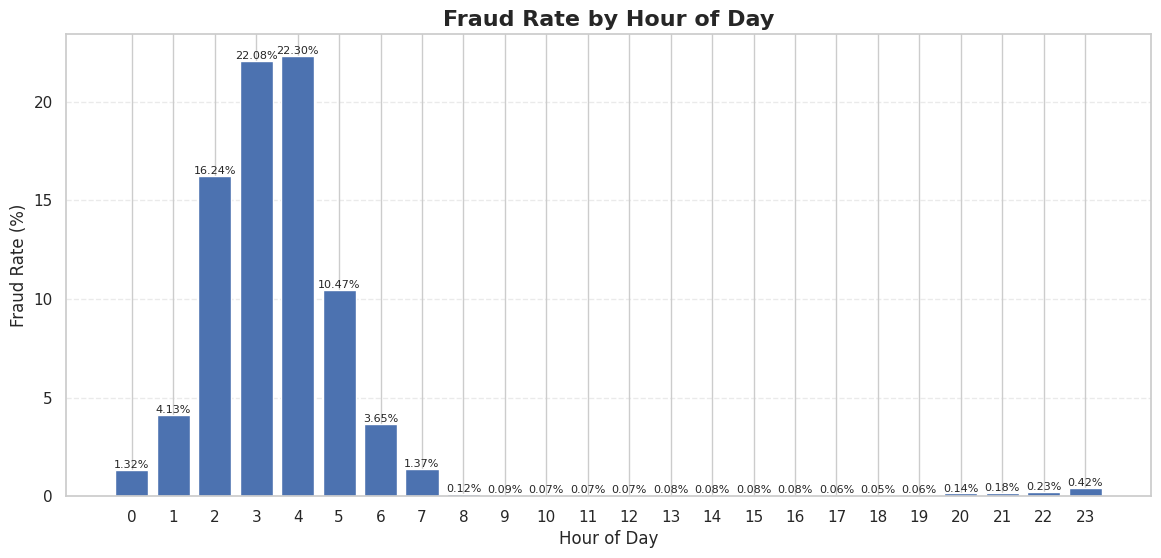

In [43]:
fraud_rate_hour = (
    df.groupby('hour_of_day')['isFraud']
    .mean()
    .mul(100)
)

plt.figure(figsize=(14, 6))

bars = plt.bar(
    fraud_rate_hour.index.astype(str),
    fraud_rate_hour.values
)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{y:.2f}%',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title(
    'Fraud Rate by Hour of Day',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

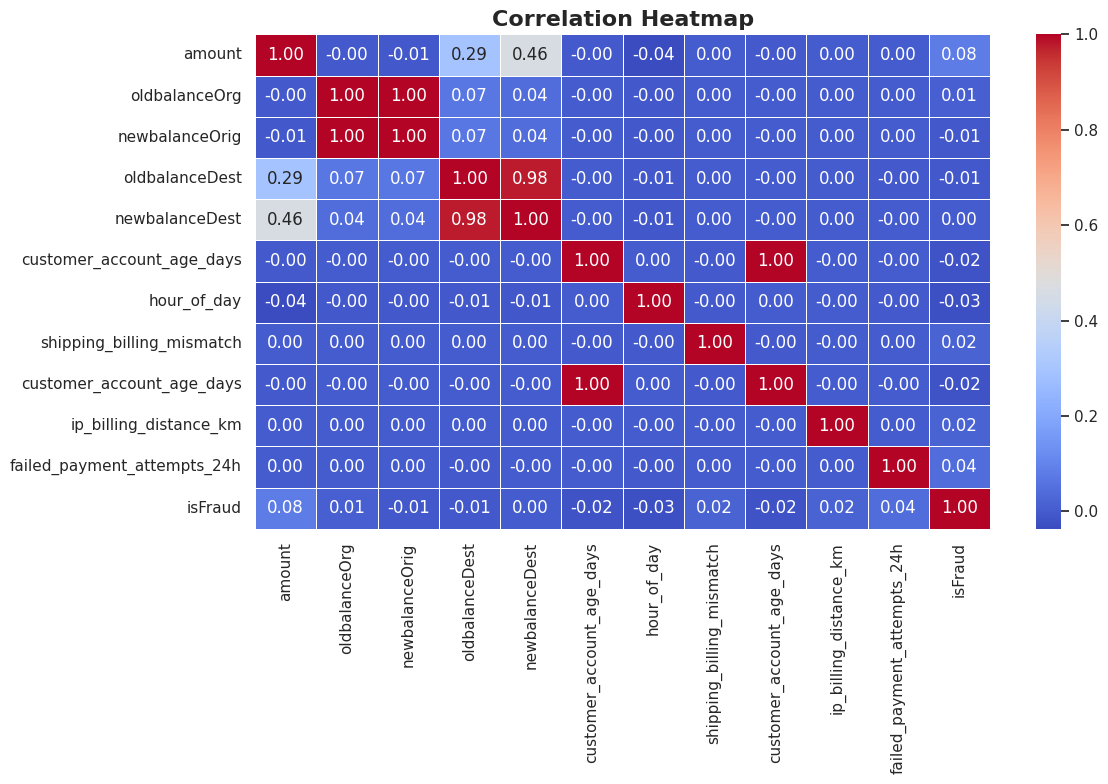

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'customer_account_age_days',
    'hour_of_day',
    'shipping_billing_mismatch',
    'customer_account_age_days',
    'ip_billing_distance_km',
    'failed_payment_attempts_24h',
    'isFraud'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title(
    'Correlation Heatmap',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

The correlation analysis shows that no single feature has a strong linear relationship with fraud transactions. Among all variables, `amount` has the highest positive correlation with `isFraud`, indicating that larger transactions are slightly more likely to be fraudulent. Features such as `failed_payment_attempts_24h`, `shipping_billing_mismatch`, and `ip_billing_distance_km` also show weak positive correlations with fraud, suggesting suspicious behavioral patterns.

In contrast, `customer_account_age_days` has a slight negative correlation with fraud, implying that newer accounts tend to be riskier.

# Business Insights

The analysis suggests that fraudulent transactions are more likely to involve high transaction amounts, newly created accounts, multiple failed payment attempts, and mismatches between billing and shipping information. These patterns indicate that fraudsters often exploit newly registered accounts and attempt suspicious transactions with unusual payment behaviors.

From a business perspective, these findings can help financial institutions and payment platforms strengthen their fraud prevention strategies. For example, transactions with unusually large amounts or repeated failed attempts can be flagged for additional verification. Similarly, accounts with very short account age or significant geographic mismatches between IP and billing locations may require enhanced monitoring.

The results also highlight the importance of combining multiple behavioral and transactional signals rather than relying on a single indicator. Implementing real-time risk scoring based on these combined features could help reduce financial losses while minimizing disruption for legitimate customers.